# Lattice thermal conductivity via `calculate_phonon_thermal_conductivity`

Computes the lattice thermal conductivity tensor κ(T) of Cu FCC using phono3py.
The macro fans out FC2 + FC3 force evaluations through the existing `Engine` Protocol
(here the ASE EMT calculator), fits the force constants, and runs the linearised
Boltzmann transport equation on a coarse q-mesh.

EMT is a toy potential — the absolute κ value here is unphysical. Use a foundation
MLIP (MACE, GRACE, etc.) or DFT engine for production-quality numbers; the workflow
graph is identical.

In [1]:
import numpy as np
from ase.build import bulk
from ase.calculators.emt import EMT

from pyiron_workflow_atomistics.engine import ASEEngine, CalcInputStatic
from pyiron_workflow_atomistics.physics.phonons import (
    calculate_phonon_thermal_conductivity,
)

structure = bulk("Cu", "fcc", a=3.6)
engine = ASEEngine(
    EngineInput=CalcInputStatic(),
    calculator=EMT(),
    working_directory="./_phonon_runs",
)

In [2]:
wf = calculate_phonon_thermal_conductivity(
    structure=structure,
    engine=engine,
    fc2_supercell_matrix=(2 * np.eye(3)).astype(int),
    temperatures=[100.0, 200.0, 300.0, 500.0, 700.0],
    q_mesh=(7, 7, 7),
    mode_resolved=True,
    harmonic_observables=True,
)
wf.run()
out = wf.outputs.phonon_output.value

In [3]:
for T, kappa in zip(out.temperatures, out.kappa):
    diag = np.diag(kappa)
    print(f"T = {T:5.0f} K   kappa_diag = {diag} W/(m K)")

T =   100 K   kappa_diag = [9.6715743e+36 9.6715743e+36 9.6715743e+36] W/(m K)
T =   200 K   kappa_diag = [5.53296508e+36 5.53296508e+36 5.53296508e+36] W/(m K)
T =   300 K   kappa_diag = [3.80093177e+36 3.80093177e+36 3.80093177e+36] W/(m K)
T =   500 K   kappa_diag = [2.31758286e+36 2.31758286e+36 2.31758286e+36] W/(m K)
T =   700 K   kappa_diag = [1.66293422e+36 1.66293422e+36 1.66293422e+36] W/(m K)


## Phonon band structure + DOS

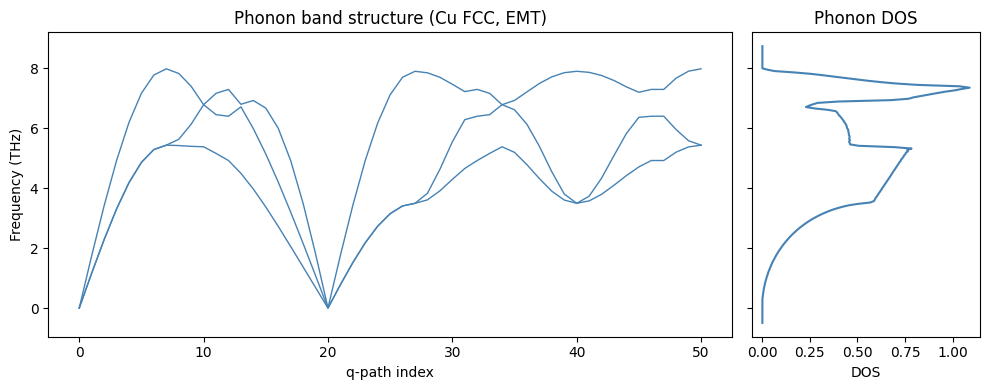

In [4]:
import matplotlib.pyplot as plt

fig, (ax_band, ax_dos) = plt.subplots(
    1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [3, 1]}, sharey=True
)

bs = out.band_structure
for branch in range(bs["frequencies"].shape[1]):
    ax_band.plot(bs["frequencies"][:, branch], color="steelblue", linewidth=1)
ax_band.set_xlabel("q-path index")
ax_band.set_ylabel("Frequency (THz)")
ax_band.set_title("Phonon band structure (Cu FCC, EMT)")

dos = out.dos
ax_dos.plot(dos["dos"], dos["frequencies"], color="steelblue")
ax_dos.set_xlabel("DOS")
ax_dos.set_title("Phonon DOS")

plt.tight_layout()
plt.show()

## κ(T)

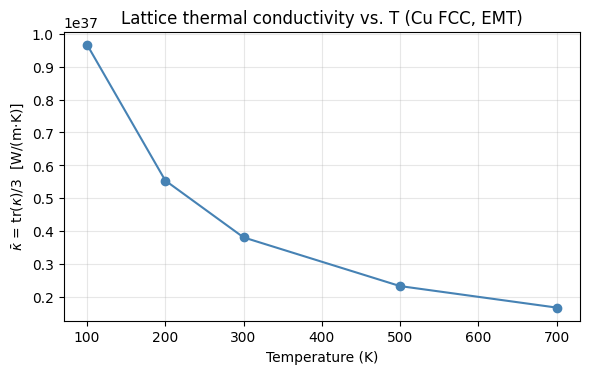

In [5]:
kappa_avg = np.array(
    [np.trace(kT) / 3.0 for kT in out.kappa]
)  # isotropic average

plt.figure(figsize=(6, 4))
plt.plot(out.temperatures, kappa_avg, marker="o", color="steelblue")
plt.xlabel("Temperature (K)")
plt.ylabel(r"$\bar{\kappa}$ = tr($\kappa$)/3  [W/(m·K)]")
plt.title("Lattice thermal conductivity vs. T (Cu FCC, EMT)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Free energy F(T)

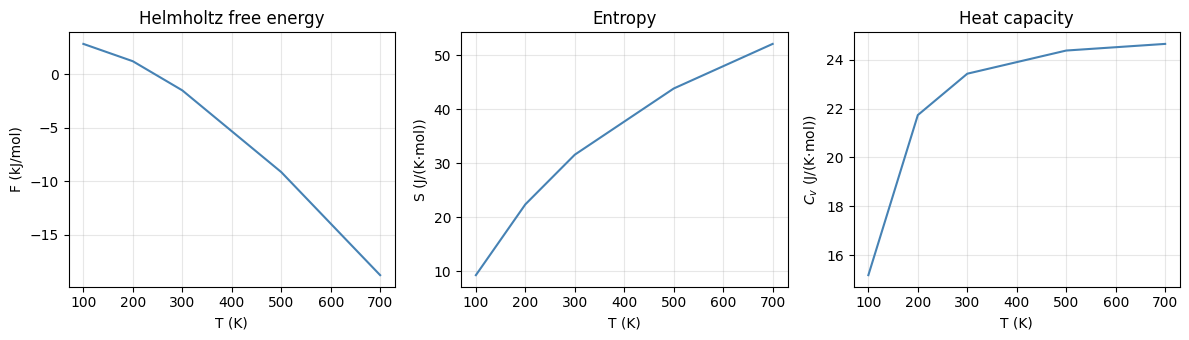

In [6]:
fe = out.free_energy
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].plot(fe["temperatures"], fe["F"], color="steelblue")
axes[0].set_xlabel("T (K)")
axes[0].set_ylabel("F (kJ/mol)")
axes[0].set_title("Helmholtz free energy")
axes[1].plot(fe["temperatures"], fe["S"], color="steelblue")
axes[1].set_xlabel("T (K)")
axes[1].set_ylabel("S (J/(K·mol))")
axes[1].set_title("Entropy")
axes[2].plot(fe["temperatures"], fe["Cv"], color="steelblue")
axes[2].set_xlabel("T (K)")
axes[2].set_ylabel("$C_v$ (J/(K·mol))")
axes[2].set_title("Heat capacity")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()